## Preparation

### Libraries import & metadata storage definitions

In [1]:
import os
import numpy as np
from time import time
from typing import Optional

import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import root_mean_squared_error
from scipy.stats import linregress
from scipy.special import softmax

from matplotlib import pyplot as plt, colors, cm

In [2]:
checkpoint_dir = "checkpoints_imagenet"
graph_dir = "graphs_imagenet"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Common key functions: plots

In [3]:
figsize_squared = (30, 7)
figsize_long = (3, 15)

In [4]:
def plot_metric(trains: list, 
                tests: list, 
                epochs: int, 
                model_name: str = "model",
                dataset_name: str = "dataset",
                metric_name: str = "metric",
                trains_name: str = "",
                tests_name: str = "",
                graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        [i+1 for i in range(epochs)],
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label= trains_name or "train " + metric_name
    )
    ax.plot(
        [i+1 for i in range(epochs)],
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label= tests_name or "test " + metric_name
    )
    ax.set(
        title=f"{model_name} {metric_name} on {dataset_name} for {epochs} epochs",
        xlabel="epochs", xlim=(-1, epochs+1), xticks=[i for i in range(0, epochs+1, 5)],
        ylabel=metric_name
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))
    

def centralize_colormap(values, 
                        center: float = 0):
    values_min = np.min(values)
    values_max = np.max(values)
    border = max(abs(values_min), abs(values_max))
    
    return colors.TwoSlopeNorm(
        vmin=-border,
        vcenter=center, 
        vmax=border
    )


def plot_heatmap(values,
                 figsize = None,
                 cmap_name: str = "seismic",
                 title: str = "Weights heatmap"):    
    plt.figure(figsize=figsize or (25, 3))
    plt.imshow(
        values, 
        origin="lower",
        cmap=cmap_name, 
        norm=centralize_colormap(values),
        extent=(0, len(values[0]) + 1, 0, len(values) + 1)
    )  
    plt.title(title)  
    plt.colorbar()  
    plt.show() 


def plot_colored_barplot(values,
                         values_color,
                         values_color_name: str,
                         cmap_name: str = "seismic",
                         edge_color: str = "black",
                         title: str = "Values barplot",
                         xlabel: str = "",
                         ylabel: str = "",
                         xticks: list = [],
                         xticklabels: list = []):
    fig, ax = plt.subplots(figsize=(25, 5))
    
    values_cmap = plt.get_cmap(cmap_name)
    norm = centralize_colormap(values_color)
    ax.bar(
        [i for i in range(len(values))],
        values, 
        color=values_cmap(norm(values_color)),
        edgecolor=edge_color
    )
    
    scalar_map = cm.ScalarMappable(
        cmap=values_cmap, 
        norm=norm
    )
    scalar_map.set_array([])
    colorbar = plt.colorbar(scalar_map, ax=ax)
    colorbar.set_label(values_color_name)
    
    if len(xticks):
        ax.set(
            title=title,
            xlabel=xlabel,
            xticks=xticks,
            ylabel=ylabel
        )
        if not xticklabels:
            xticklabels = xticks
        ax.set_xticklabels(xticklabels, rotation=-45)
    else:
        ax.set(
            title=title,
            xlabel=xlabel,
            ylabel=ylabel
        )
    plt.grid(True, alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show() 

## Dataset download & instantiation

### ImageNet-1K

В работе рассматривается задача классификации изображений, для которой используются модель [семейства RegNet](https://docs.pytorch.org/vision/main/models/regnet.html) версии RegNet_Y_3_2_GF и датасет [ImageNet-1K (ILSVRC2017)](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview). 

Датасет ImageNet содержит высокого (различного) разрешения, каждое из которых аннотировано с использованием синсетов WordNet и соотносится с 1 или более из 1000 классов; классы не сбалансированы. Подсеты имеют следующую мощность:
- train - 1,3 млн изображений,
- val - 50 тыс изображений,
- test - 100 тыс изображений.

Модель для ускорения обучения инициализируется весами, предобученными на датасете ImageNet со следующими метриками точности:
- acc1: 78.948,
- acc5: 94.576

без дообучения.

In [5]:
def make_val_loader_imagenet(val_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4,
                             picture_size: int = 224):
    transforms_val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(picture_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    imagenet_val = datasets.ImageNet(
        root=val_dir, 
        split="val", 
        transform=transforms_val
    )

    return DataLoader(
        imagenet_val, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers, 
        pin_memory=True
    )

In [6]:
dataset_dir_imagenet = "/media/user/Hitachi/ILSVRC/Data/CLS-LOC"
dataset_name = "ImageNet"
picture_size = 224

n_classes = 1000
batch_size = 128
num_workers = 4

In [7]:
print(f"[ ] Creating dataset {dataset_name}...")
val_loader = make_val_loader_imagenet(dataset_dir_imagenet, batch_size, num_workers)
classes_names = val_loader.dataset.classes  # type: ignore
print(f"[V] Dataset {dataset_name} created")

[ ] Creating dataset ImageNet...
[V] Dataset ImageNet created


## Model preparation

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


### RegNetX_3_2 download & instantiation

In [9]:
print("[ ] Instantiating model...")
regnety_3_2 = models.regnet_y_3_2gf(weights=models.RegNet_Y_3_2GF_Weights.DEFAULT, progress=True)
regnety_3_2.to(device)
regnety_3_2_name = "RegNetY_3_2"
print(f"[V] {regnety_3_2_name} with default weights instantiated")

[ ] Instantiating model...
Downloading: "https://download.pytorch.org/models/regnet_y_3_2gf-9180c971.pth" to /home/user/.cache/torch/hub/checkpoints/regnet_y_3_2gf-9180c971.pth


100.0%


[V] RegNetY_3_2 with default weights instantiated


## Main pipeline

### Pipeline: validation, binarization, weights fuse

In [ ]:
seed = 42
torch.manual_seed(seed)

@torch.inference_mode()
def validate_top1_top5_time(model, 
                            loader: DataLoader):
    device = next(model.parameters()).device

    model.eval()
    top1_correct = 0
    top5_correct = 0
    total = 0
    
    start_time = time()

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        _, preds = logits.topk(5, dim=1, largest=True, sorted=True)

        correct = preds.eq(targets.view(-1, 1))
        top1_correct += correct[:, :1].sum().item()
        top5_correct += correct.sum().item()
        total += targets.size(0)
        
    val_time = time() - start_time

    return (top1_correct / total * 100,
            top5_correct / total * 100,
            val_time)
    
def pretty_print_top1_top5_time(model, 
                                loader: DataLoader, 
                                top1_orig: float = 0,
                                top5_orig: float = 0):    
    top1_new, top5_new, val_time = validate_top1_top5_time(model, loader)
    
    if top1_orig:
        drop1 = top1_orig - top1_new
        drop1_report = f", drop: {drop1:.4f}"
    else:
        drop1, drop1_report = None, ""
    if top5_orig:
        drop5 = top5_orig - top5_new
        drop5_report = f", drop: {drop5:.4f}"
    else:
        drop5, drop5_report = None, ""
        
    print(f"    Top-1 Accuracy:  {top1_new:.4f}{drop1_report}")
    print(f"    Top-5 Accuracy:  {top5_new:.4f}{drop5_report}")
    print(f"    Validation time: {val_time:.4f} s")
    return top1_new, top5_new, val_time, drop1, drop5


avgpool_input_float, avgpool_input_bin, avgpool_input_bin_values = [], [], []
scale_bin_coeff = 6   # scaling coefficient for binarization hook from 'ADD-ONs: Binarizarion function choice'
def binarize_hook(module, input):
    x, = input
    x_bin = 2 ** ((x+1).log2().mul(1/scale_bin_coeff).round().mul(scale_bin_coeff)) - 1
    
    global avgpool_input_float, avgpool_input_bin, avgpool_input_bin_values
    avgpool_input_float = x
    avgpool_input_bin = x_bin
    avgpool_input_bin_values = x_bin.unique()
    
    return (x_bin,)

fc_input = []
def get_fc_input_hook(module, input):
    global fc_input
    x, = input
    fc_input = x.detach()

In [ ]:
class RegNetAvgPoolFCFused(torch.nn.Module):
    def __init__(self, original_model, fused_fc_layer):
        super().__init__()
        self.stem = original_model.stem
        self.trunk_output = original_model.trunk_output
        self.fused_fc = fused_fc_layer
            
    def forward(self, x):
        x = self.stem(x)
        x = self.trunk_output(x)  # -> [batch_size, 1512, 7, 7] for RegNetY_3_2 on ImageNet
        x = x.flatten(1)          # -> [batch_size, 1512*7*7] + normalization for RegNetY_3_2 on ImageNet
        x = self.fused_fc(x)      # -> [batch_size, 1000]       for RegNetY_3_2 on ImageNet
        return x


def fuse_avgpool_linear(model, 
                        input_size: int = 224):
    device = next(model.parameters()).device
    
    weights = model.fc.weight.data  # [1000, 1512] for RegNetY_3_2 on ImageNet
    bias = model.fc.bias.data if (model.fc.bias is not None) else torch.zeros(weights.shape[0])
    
    with torch.no_grad():
        random_input = torch.randn(1, 3, input_size, input_size).to(device)
        features = model.stem(random_input)
        features = model.trunk_output(features)
        H, W = features.shape[-2:] # shape = [batch, channels, H, W] = [batch_size, 1512, 7, 7] for RegNetY_3_2 on ImageNet
    
    divisor = H * W
    weights_fused = weights.repeat_interleave(divisor, dim=1) / divisor
    
    return weights_fused.to(device), bias.to(device)


def replace_fc_fused_weights(model, 
                             input_size: int = 224):
    device = next(model.parameters()).device
    
    weights_fused, bias_fused = fuse_avgpool_linear(model, input_size)
    
    print("Replacing fc layer with fused one with following architecture:")
    print("    original in_features:", model.fc.in_features)
    print("    fused in_features:   ", weights_fused.shape[1])
    print("    original out_features:", model.fc.out_features)
    print("    original out_features:", weights_fused.shape[0])
    
    avgpool_fc = torch.nn.Linear(
        in_features=weights_fused.shape[1],
        out_features=model.fc.out_features,
        bias=True
    ).to(device)
    
    avgpool_fc.weight.data = weights_fused
    avgpool_fc.bias.data = bias_fused
        
    return RegNetAvgPoolFCFused(
        model, 
        avgpool_fc
    ).to(device)
    

def verify_fusion_equivalence(orig_model, 
                              fused_model, 
                              input_size: int = 224, 
                              num_tests: int = 10):
    device = next(orig_model.parameters()).device
    orig_model.eval()
    fused_model.eval()
    
    max_diff = 0.0
    with torch.no_grad():
        for _ in range(num_tests):
            x = torch.randn(2, 3, input_size, input_size, device=device)
            output_orig_model = orig_model(x)
            output_fused_model = fused_model(x)
            current_diff = torch.max(torch.abs(output_orig_model - output_fused_model)).item()
            max_diff = max(max_diff, current_diff)
    
    print(f"\nModels equivalence test on {num_tests} random inputs: {max_diff}")
    return output_orig_model, output_fused_model

In [ ]:
print("\nValidating model before binarizing:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnety_3_2, val_loader
)

In [ ]:
print("\n2. Binarizing input of avgpool layer...\n")
regnety_3_2.avgpool.register_forward_pre_hook(binarize_hook)

print("\n[ ] Validating model after binarizing avgpool input:")
top1_bin, top5_bin, val_time, _, _ = pretty_print_top1_top5_time(
    regnety_3_2, val_loader, 
    top1_orig=top1_orig, 
    top5_orig=top5_orig
)


2. Binarizing input of avgpool layer...



In [15]:
print("Binary values of last layer input:")
avgpool_input_bin_values

Binary values of last layer input:


[]

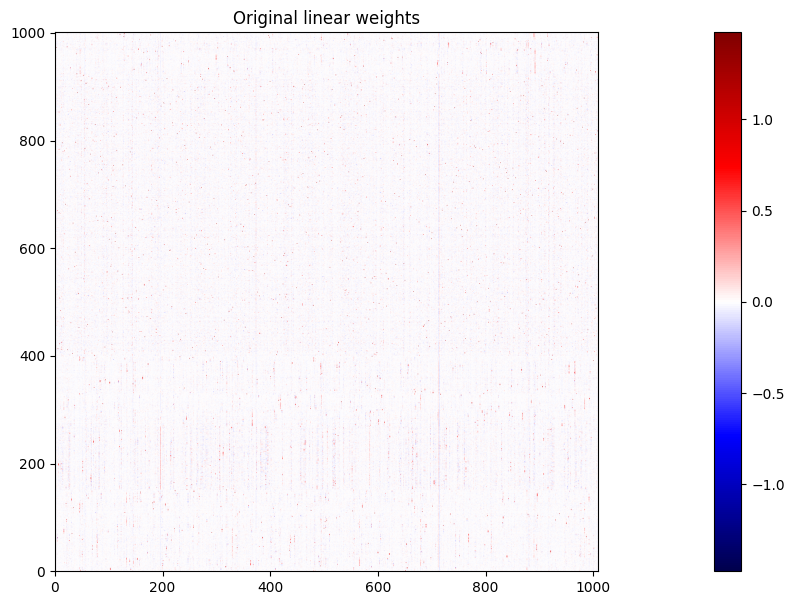

In [ ]:
plot_heatmap(
    regnety_3_2.fc.weight.data.cpu().numpy(), 
    figsize=figsize_squared, 
    title="Original linear weights"
)

In [ ]:
print("\n3. Avgpool and linear layers fusing...\n")
weights_fused, bias_fused = fuse_avgpool_linear(regnety_3_2, picture_size)
print("    Fused weight matrix shape:", weights_fused.shape)  # [n_classes, 1512*H*W]


3. Avgpool and linear layers fusing...

    Fused weight matrix shape: torch.Size([1000, 49392])


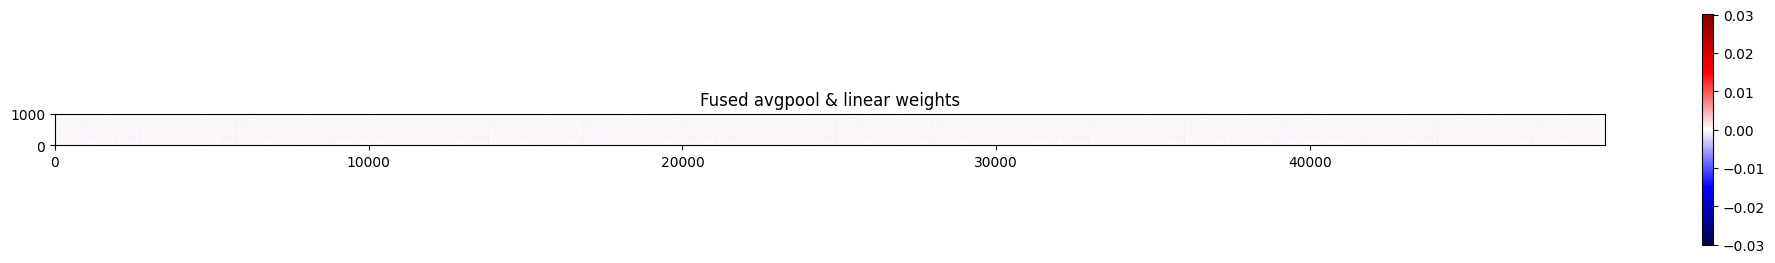

In [18]:
plot_heatmap(
    weights_fused.cpu().numpy(), 
    title="Fused avgpool & linear weights"
)

### Significant features extraction

In [19]:
torch.manual_seed(seed)

n_svd_components = 100

print("\n4. Fused avgpool and linear layer SVD...\n")
svd = TruncatedSVD(n_components=n_svd_components, random_state=seed)
weights_reduced = svd.fit_transform(weights_fused.cpu())
print("    Explained variance ratio:", svd.explained_variance_ratio_.sum())


4. Fused avgpool and linear layer SVD...

    Explained variance ratio: 0.2805419


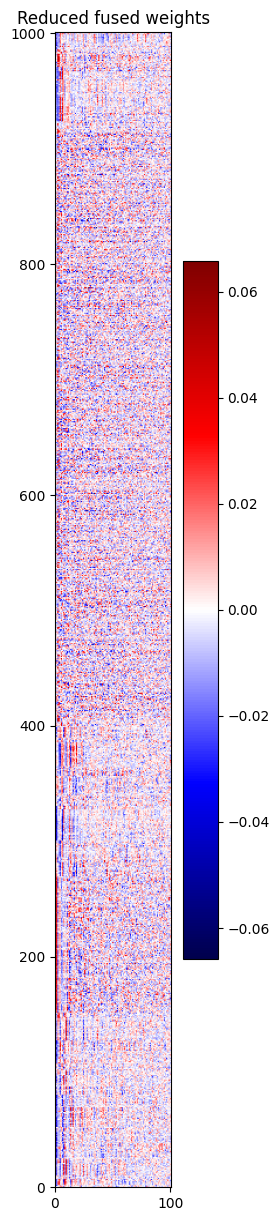

In [20]:
plot_heatmap(weights_reduced, figsize=figsize_long, title="Reduced fused weights")

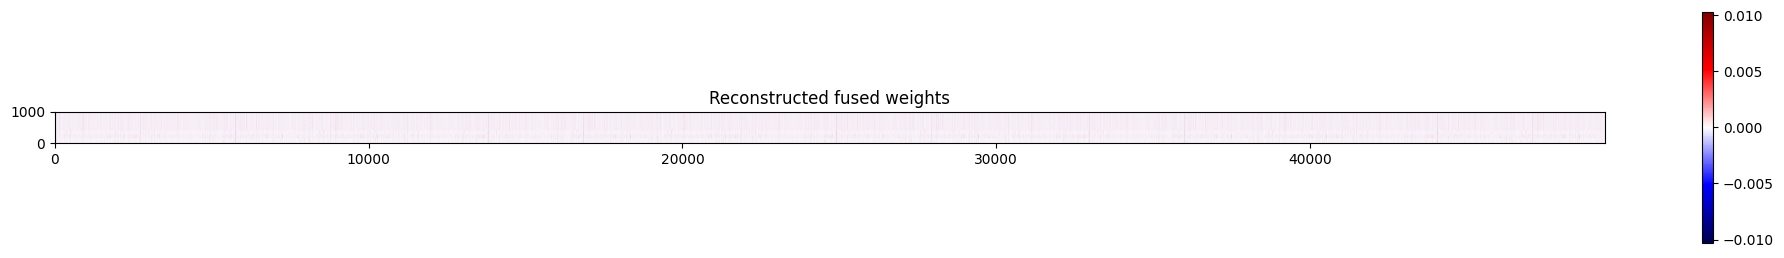

Reconstruction RMSE:      0.000804


In [ ]:
svd_right_sing_vecs = svd.components_  # [n_svd_components, 1512*H*W]
weights_reconstructed = svd.inverse_transform(weights_reduced)

plot_heatmap(weights_reconstructed, title="Reconstructed fused weights")
print(f"Reconstruction RMSE:\
      {root_mean_squared_error(weights_fused.cpu().numpy(), weights_reconstructed):.6f}")

### SVD details analysis


5. Extracting significant features...



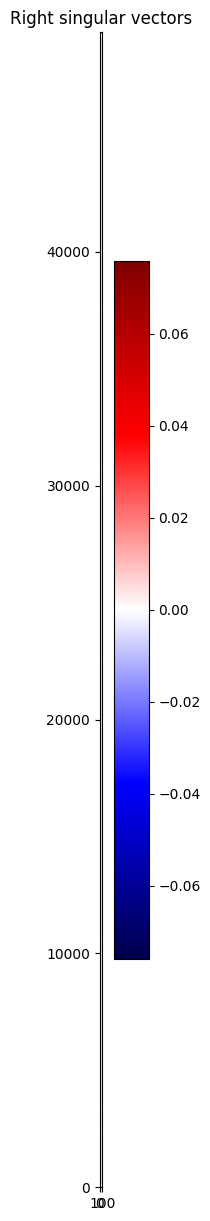

In [22]:
print("\n5. Extracting significant features...\n")

plot_heatmap(
    np.transpose(svd_right_sing_vecs), 
    figsize=figsize_long,
    title="Right singular vectors"
)

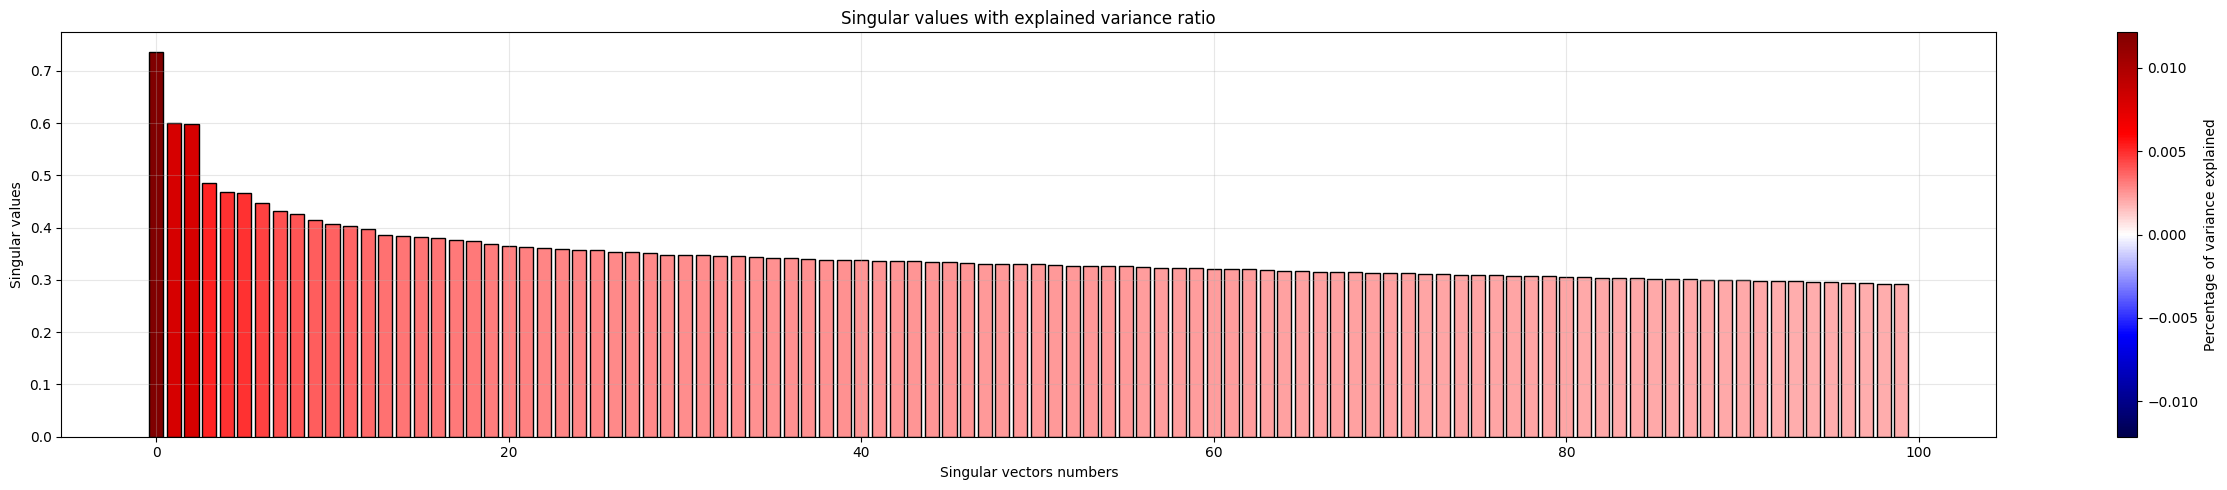

In [23]:
svd_sing_values = svd.singular_values_
svd_expl_var_ratio = svd.explained_variance_ratio_

plot_colored_barplot(
    values=svd_sing_values,
    values_color=svd_expl_var_ratio,
    values_color_name="Percentage of variance explained",
    title="Singular values with explained variance ratio",
    xlabel="Singular vectors numbers",
    ylabel="Singular values"
)

In [24]:
print("Top-5 singular values:                ", svd_sing_values[:5])
print("Top-5 (according) explained variences:", svd_expl_var_ratio[:5])

Top-5 singular values:                 [0.7366367  0.6000917  0.59729344 0.48479182 0.46854857]
Top-5 (according) explained variences: [0.01213399 0.00805251 0.0079776  0.00525541 0.00490914]


### Significant features count as: singular vectors, reduced features, reconstructed features

In [25]:
def calc_ljust_spaces(signific_thresholds: list):
    n = 3
    
    thresholds_str = []
    for thr in signific_thresholds:
        thr_str = f"{thr:.{n}f}"
        thresholds_str.append(
            thr_str.rstrip('0').rstrip('.') if ('.' in thr_str) else thr_str
        )
    return thresholds_str, max(len(thr_str) for thr_str in thresholds_str) 


def signific_features_count(weights,
                            signific_thresholds: list,
                            weights_name: str = "",
                            is_strict: bool = False,
                            is_return: bool = False):
    signific_features_percent = {}
    thresholds_str, max_threshold_len = calc_ljust_spaces(signific_thresholds)
    
    signific_features_ns =  [ np.sum(np.abs(weights) > threshold) 
                             for threshold in signific_thresholds ] \
                            if is_strict else \
                            [ np.sum(np.abs(weights) >= threshold) 
                             for threshold in signific_thresholds ]

    print(f"    Percent of significant {weights_name} features:")
    sign = ">" if is_strict else ">="
    for i in range(len(signific_thresholds)):
        part = signific_features_ns[i] / weights.size
        print(
            f"        {sign} {thresholds_str[i].ljust(max_threshold_len)}: ", 
            f"{part:.5%}"        
        )
        signific_features_percent[thresholds_str[i]] = part * 100
    print("    of all features after SVD")
    
    return signific_features_percent \
           if is_return else None

In [26]:
print("\n6.1 Counting significant singular features...\n")

signific_sing_thresholds = [0.01, 0.015, 0.02, 0.025, 0.05, 0.075, 0.1] # , 0.1, 0.15, 0.2, 0.25, 0.5, 0.75
signific_features_count(svd_right_sing_vecs, signific_sing_thresholds, "singular")


6.1 Counting significant singular features...

    Percent of significant singular features:
        >= 0.01 :  3.37798%
        >= 0.015:  0.60020%
        >= 0.02 :  0.15476%
        >= 0.025:  0.06250%
        >= 0.05 :  0.00893%
        >= 0.075:  0.00099%
        >= 0.1  :  0.00000%
    of all features after SVD


In [27]:
print("\n6.2 Counting significant reduced features...\n")

signific_red_thresholds = [0.01, 0.015, 0.02, 0.025, 0.05, 0.075, 0.1] # , 0.1, 0.15, 0.2, 0.25, 0.5, 0.75
signific_features_count(weights_reduced, signific_red_thresholds, "reduced")


6.2 Counting significant reduced features...

    Percent of significant reduced features:
        >= 0.01 :  33.06400%
        >= 0.015:  16.07400%
        >= 0.02 :  7.55800%
        >= 0.025:  3.52800%
        >= 0.05 :  0.03200%
        >= 0.075:  0.00000%
        >= 0.1  :  0.00000%
    of all features after SVD


In [28]:
print("\n6.3 Counting significant reconstructed features...\n")

signific_rec_thresholds = [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.0075, 0.01, 0.015] # , 0.1, 0.15, 0.2, 0.25, 0.5, 0.75
signific_features_count(
    weights_reconstructed, 
    signific_rec_thresholds, 
    "(binary in perspective) reconstructed"
)


6.3 Counting significant reconstructed features...

    Percent of significant (binary in perspective) reconstructed features:
        >= 0.001:  3.79435%
        >= 0.002:  1.29196%
        >= 0.002:  0.67133%
        >= 0.003:  0.40387%
        >= 0.005:  0.06280%
        >= 0.007:  0.00714%
        >= 0.01 :  0.00020%
        >= 0.015:  0.00000%
    of all features after SVD


## Codebook extraction experiments

In [ ]:
regnety_3_2_fused_fc = replace_fc_fused_weights(regnety_3_2, picture_size)
verify_fusion_equivalence(regnety_3_2, regnety_3_2_fused_fc)
print(regnety_3_2_fused_fc)

Replacing fc layer with fused one with following architecture:
    original in_features: 1008
    fused in_features:    49392
    original out_features: 1000
    original out_features: 1000

Models equivalence test on 10 random inputs: 16.3877010345459
RegNetAvgPoolFCFused(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 96, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(96,

In [ ]:
regnety_3_2.fc.weight.data

tensor([[-0.0037, -0.0130, -0.0112,  ..., -0.0065,  0.0245, -0.0176],
        [ 0.0024, -0.0172,  0.0353,  ..., -0.0168, -0.0252,  0.0011],
        [-0.0121, -0.0085,  0.0192,  ..., -0.0304, -0.0018,  0.0216],
        ...,
        [-0.0254, -0.0190,  0.0017,  ...,  0.0326,  0.0136, -0.0059],
        [-0.0232,  0.0259, -0.0113,  ...,  0.0186, -0.0139, -0.0239],
        [-0.0046, -0.0375, -0.0460,  ...,  0.0272,  0.0212,  0.0143]],
       device='cuda:0')

In [ ]:
regnety_3_2_fused_fc.fused_fc.weight.data * 49

tensor([[-0.0256, -0.0908, -0.0787,  ..., -0.0455,  0.1715, -0.1230],
        [ 0.0166, -0.1202,  0.2470,  ..., -0.1177, -0.1762,  0.0075],
        [-0.0845, -0.0596,  0.1344,  ..., -0.2131, -0.0123,  0.1511],
        ...,
        [-0.1775, -0.1330,  0.0120,  ...,  0.2285,  0.0949, -0.0410],
        [-0.1623,  0.1815, -0.0793,  ...,  0.1299, -0.0975, -0.1674],
        [-0.0320, -0.2628, -0.3217,  ...,  0.1905,  0.1486,  0.1001]],
       device='cuda:0')

In [ ]:
print("7. Fused weights inception for further experiments...")

# regnety_3_2_fused_fc = replace_fc_fused_weights(regnety_3_2, picture_size)
print("\nValidating model after fusing avgpool with fc:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnety_3_2_fused_fc, val_loader
)

7. Fused weights inception for further experiments...
Replacing fc layer with fused one with following architecture:
    original in_features: 1008
    fused in_features:    49392

Validating model after fusing avgpool with fc:
    Top-1 Accuracy:  0.0580
    Top-5 Accuracy:  0.3880
    Validation time: 508.8070 s


### Extractor class definition

In [ ]:
class BoostingCodebookExtractor:
    def __init__(self, 
                 max_codewords_per_class: int = 10,
                 divergence_type: str = "KL",
                 is_refinement: bool = True,
                 refinement_radius: int = 1,
                 div_limit: float = 1e-4,
                 max_iter: int = 100,
                 random_state: Optional[int] = None):
        """
        Parameters
        ----------
        max_codewords_per_class : int
            Maximum code words number per class
        divergence_type : str
            Divergence type in {'KL', 'L2'}
        is_refinement : bool
            Whether to use codewords local refinement or not
        refinement_radius : int
            Hamming radius for refinement
        div_limit : float
            Divergence sufficient limit for early-stopping
        max_iter : int
            Maximum iterations number
        random_state : int
        """
        self.max_codewords_per_class = max_codewords_per_class
        assert divergence_type in ["KL", "L2"], "Divergence type must be in {'KL', 'L2'}"
        self.divergence_type = divergence_type
        self.is_refinement = is_refinement
        self.refinement_radius = refinement_radius
        self.div_limit = div_limit
        self.max_iter = max_iter
        self.random_state = random_state
        
        self.codebooks_ = [[]]
        self.lambda_ = 0
        self.betas_ = []
        self.n_features_ = 0
        self.n_classes_ = 0
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _hamming_distance(self, 
                          X: np.ndarray, 
                          codeword: np.ndarray) -> np.ndarray:
        """
        Compute Hamming distance between soft-binary vectors and binary codeword
        
        Parameters
        ----------
        X: np.ndarray, shape (n_samples, n_features)
            Soft-binary vectors
        codeword : np.ndarray, shape (n_features,)
            Binary codeword
            
        Returns
        --------
        distances : np.ndarray, shape (n_samples,)
            Hamming distance
        """
        return np.sum(X * (1 - codeword) + (1 - X) * codeword, axis=1)  # expected sum_j [ x_j*(1-c_j) + (1-x_j)*c_j ]
    
    def _compute_student_logits(self, X: np.ndarray) -> np.ndarray:
        """
        Compute student's logits for all classes
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary vectors
            
        Returns
        --------
        s_logits : np.ndarray, shape (n_samples, n_classes)
        """
        n_samples = X.shape[0]
        s_logits = np.zeros((n_samples, self.n_classes_))
        
        for class_idx in range(self.n_classes_):
            if not self.codebooks_[class_idx]:    # for no codeworks large distance is used
                min_dists = np.full(n_samples, self.n_features_)
            else:                                 # calcuate distance to all codewords of the class
                dists = np.column_stack([
                    self._hamming_distance(X, codeword) 
                    for codeword in self.codebooks_[class_idx]
                ])
                min_dists = np.min(dists, axis=1)
            
            # s_y(x) = -lambda * min_{c in C(y)} d_H(x,c) + beta_y
            s_logits[:, class_idx] = -self.lambda_ * min_dists + self.betas_[class_idx]
        
        return s_logits
    
    def _compute_divergence(self, 
                            t_logits: np.ndarray, 
                            s_logits: np.ndarray) -> np.ndarray:
        """
        Compute divergence between teacher & student logits
        
        Parameters
        -----------
        t_logits : np.ndarray, shape (n_samples, n_classes)
            Teacher logits
        s_logits : np.ndarray, shape (n_samples, n_classes)
            Student logits
            
        Returns
        --------
        divergence : np.ndarray, shape (n_samples,)
        """
        if self.divergence_type == 'L2':
            return np.linalg.norm(t_logits - s_logits, axis=1)
        else:  # KL(σ(t) || σ(s))
            epsilon = 1e-12   # for numerical stability
            t_probs = np.clip(softmax(t_logits, axis=1), epsilon, 1.0)
            s_probs = np.clip(softmax(s_logits, axis=1), epsilon, 1.0)
            return np.sum(t_probs * (np.log(t_probs) - np.log(s_probs)), axis=1)
    
    
    def _initialize_codebooks(self, 
                              X: np.ndarray, 
                              y: np.ndarray, 
                              W: Optional[np.ndarray] = None) -> None:
        """
        Codebooks initialization
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features
        y : np.ndarray, shape (n_samples,)
            Classes labels vector
        W : np.ndarray, shape (n_classes, n_features), optional
            fc.weights for bit calibration
        """
        n_samples, n_features = X.shape
        
        if W is not None:
            s = np.sign(np.sum(W, axis=0))
            for j in range(n_features):
                if s[j] < 0:
                    X[:, j] = 1 - X[:, j]
        
        self.codebooks_ = [[] for _ in range(self.n_classes_)]
        
        for class_idx in range(self.n_classes_):
            class_mask = (y == class_idx)
            if np.sum(class_mask) > 0:
                mean_bits = np.mean(X[class_mask], axis=0)
                self.codebooks_[class_idx].append(
                    (mean_bits >= 0.5).astype(np.float64)
                )
            else:
                self.codebooks_[class_idx].append(
                    np.random.randint(0, 2, n_features).astype(np.float64)
                )
        

        self._calibrate_parameters(X, y)
    
    def _calibrate_parameters(self, 
                              X: np.ndarray, 
                              y: np.ndarray, 
                              t_logits: Optional[np.ndarray] = None) -> None:
        """
        Lambda & betas calibration
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features
        y : np.ndarray, shape (n_samples,)
            Classes labels
        t_logits : np.ndarray, shape (n_samples, n_classes), optional
            Teacher's logits. When `None`, `t_logits` from `fit` is used
        """
        n_samples = X.shape[0]
        
        distances = np.zeros(n_samples)
        for i in range(n_samples):
            class_idx = y[i]
            if self.codebooks_[class_idx]:
                dists = [
                    self._hamming_distance(X[i:i+1], c)[0] 
                    for c in self.codebooks_[class_idx]
                ]
                distances[i] = np.min(dists)
            else:
                distances[i] = self.n_features_
        
        if t_logits is None:
            t_logits = self.t_logits_
        t_target = t_logits[np.arange(n_samples), y]
        
        # Linear regression: t_i \approx \alpha + \beta * d_i
        slope, intercept, r_value, p_value, std_err, intercept_err = stats.linregress(distances, t_target)
        
        self.lambda_ = -slope
        self.betas_ = np.full(self.n_classes_, intercept)
    
    def _refine_codeword(self, 
                         X_class: np.ndarray, 
                         prototype: np.ndarray, 
                         radius: int) -> np.ndarray:
        """
        Refine codeword via majority vote over neighbors
        
        Parameters
        -----------
        X_class : np.ndarray, shape (n_class_samples, n_features)
            Same class samples
        prototype : np.ndarray, shape (n_features,)
            Prototype codeword
        radius : int
            Hamming radius
            
        Returns
        --------
        refined_codeword : np.ndarray, shape (n_features,)
            Refined codeword
        """
        neighbors = X_class[
            np.sum(
                (X_class >= 0.5).astype(int) != (prototype >= 0.5).astype(int), 
                axis=1
            ) <= radius
        ]
        return (np.mean(neighbors, axis=0) >= 0.5).astype(np.float64) \
            if len(neighbors) else \
            prototype.copy()
    
    def _reassign_and_refine(self, 
                             X: np.ndarray, 
                             y: np.ndarray) -> None:
        """
        Subclasses reassignation & codewords local finetuning
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features
        y : np.ndarray, shape (n_samples,)
            Classes labels
        """
        for class_idx in range(self.n_classes_):
            if not self.codebooks_[class_idx]:
                continue
                
            X_class = X[y == class_idx]
            if not len(X_class):
                continue
            
            # find closest codeword for every sample
            assignments = []
            for x in X_class:
                dists = [
                    self._hamming_distance(x.reshape(1, -1), c)[0] 
                    for c in self.codebooks_[class_idx]
                ]
                assignments.append(np.argmin(dists))
            assignments = np.array(assignments)
            
            # update codewords as centers of the assigned clusters
            for codeword_i in range(len(self.codebooks_[class_idx])):
                cluster_mask = (assignments == codeword_i)
                if np.sum(cluster_mask) > 0:
                    cluster_samples = X_class[cluster_mask]
                    mean_bits = np.mean(cluster_samples, axis=0)
                    new_codeword = (mean_bits >= 0.5).astype(np.float64)
                    self.codebooks_[class_idx][codeword_i] = new_codeword
    
    
    def fit(self, 
            X: np.ndarray, 
            y: np.ndarray, 
            t_logits: np.ndarray,
            W: Optional[np.ndarray] = None) -> 'BoostingCodebookExtractor':
        """
        Codebook extraction algorithm training
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features in [0,1]^n
        y : np.ndarray, shape (n_samples,)
            True labels in {0, 1, ..., C-1}
        t_logits : np.ndarray, shape (n_samples, n_classes)
            Teacher's logits
        W : np.ndarray, shape (n_classes, n_features), optional
            fc.weights for bit calibration
            
        Returns
        --------
        self : BoostingCodebookExtractor
            Trained boosting codebook extractor
        """
        n_samples, n_features = X.shape
        self.n_features_ = n_features
        self.n_classes_ = len(np.unique(y))
        self.t_logits_ = t_logits
        
        assert X.shape[0] == y.shape[0] == t_logits.shape[0], "`n_samples` are different for different objects"
        assert t_logits.shape[1] == self.n_classes_, "Classes number differs"
        if W is not None:
            assert W.shape[0] == self.n_classes_ and W.shape[1] == n_features, "Wrong shape of `W`"
        
        self._initialize_codebooks(X, y, W)
        
        for iter in range(self.max_iter):
            s_logits = self._compute_student_logits(X)
            divergences = self._compute_divergence(t_logits, s_logits)
            
            mean_divergence = np.mean(divergences)
            if mean_divergence < self.div_limit:
                print(f"EARLY STOP! Achieved mean divergence: {mean_divergence:.6f} - "
                      f"on iteration {iter}")
                break
            
            i_maxdiv = np.argmax(divergences)
            y_maxdiv = y[i_maxdiv]
            
            if len(self.codebooks_[y_maxdiv]) >= self.max_codewords_per_class:
                if not iter:
                    raise ValueError("Impossible to add a codeword: "
                                     f"reached maximum codewords number for class {y_maxdiv}")
                else:
                    print(f"Reached maximum codewords number for class {y_maxdiv}")
                    break
            
            prototype = (X[i_maxdiv] >= 0.5).astype(np.float64)
            
            X_class = X[y == y_maxdiv]
            refined_codeword = self._refine_codeword(X_class, prototype, self.refinement_radius) \
                if self.is_refinement and len(X_class) else \
                prototype
            
            self.codebooks_[y_maxdiv].append(refined_codeword)
            self._reassign_and_refine(X, y)
            self._calibrate_parameters(X, y, t_logits)
            
            if not iter % 10:
                print(f"Iteration {iter}, mean divergence: {mean_divergence:.6f}")
        
        return self
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Class prediction for new samples
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features

        Returns
        --------
        predictions : np.ndarray, shape (n_samples,)
            Predicted classes
        """
        return np.argmax(self._compute_student_logits(X), axis=1)
    
    def predict_logits(self, X: np.ndarray) -> np.ndarray:
        """
        Compute student logits for new samples
        
        Parameters
        -----------
        X : np.ndarray, shape (n_samples, n_features)
            Soft-binary features
            
        Returns
        --------
        logits : np.ndarray, shape (n_samples, n_classes)
            Student's logits
        """
        return self._compute_student_logits(X)
    
    def get_codebooks(self) -> List[List[np.ndarray]]:
        """        
        Returns
        --------
        codebooks : list of lists
        """
        return self.codebooks_
    
    def get_parameters(self) -> Tuple[float, np.ndarray]:
        """        
        Returns
        --------
        lambda : float
            Global scale
        betas : np.ndarray, shape (n_classes,)
            Bias for every class
        """
        return self.lambda_, self.betas_

### Extractor usage

In [ ]:
random_seed = 42

val_loader_len = len(val_loader.dataset) # 32000
n_features = weights_reconstructed.shape[1]
max_codewords_per_class = val_loader_len // n_classes # type: ignore
divergence_type = "KL"

print(f"Training extractor on {val_loader_len} training samples "
      "with maximum number of codewords per class:", 
      max_codewords_per_class)

Training extractor on 50000 training samples with maximum number of codewords per class: 50


In [ ]:
print("[ ] Getting training data for codebook extractor...")

soft_bin_features = np.zeros((val_loader_len, n_features), dtype=np.float32)
targets = np.zeros(val_loader_len, dtype=np.float32)
t_logits = np.zeros((val_loader_len, n_classes), dtype=np.float32)

start_filling = 0

with torch.no_grad():
    for i, (images_batch, targets_batch) in enumerate(val_loader):
        print(f"Processing batch {i}...")
        
        images_batch = images_batch.to(device, non_blocking=True)
        targets_batch = targets_batch.to(device, non_blocking=True)

        t_logits_batch = regnety_3_2(images_batch)
        print("    Got logits of shape:", t_logits_batch.shape)
        print("    Avgpool input binarized into values:", avgpool_input_bin_values.data)
        
        print("avgpool_input_bin.shape:", avgpool_input_bin.shape, "avgpool_input_float.shape", avgpool_input_float.shape)
        
        end_filling = min(start_filling + batch_size, val_loader_len)
        soft_bin_features[ start_filling : end_filling ] = avgpool_input_bin.cpu().numpy()
        targets[ start_filling : end_filling ] = targets_batch.cpu().numpy()
        t_logits[ start_filling : end_filling ] = t_logits_batch.cpu().numpy()
        
        start_filling = end_filling
        

print("[V] Training data for codebook extractor prepared with:\n"
      f"    soft binary feature matrix shape:  {soft_bin_features.shape},\n" # [val_loader_len, n_classes]
      f"    target vector shape:               {targets.shape},\n"           # [val_loader_len]
      f"    teacher model logits matrix shape: {t_logits.shape}")            # [val_loader_len, n_classes]

[ ] Getting training data for codebook extractor...
Processing batch 0...
    Got logits of shape: torch.Size([32, 1000])
    Avgpool input binarized into values: tensor([ 0., 63.], device='cuda:0')
avgpool_input_bin.shape: torch.Size([32, 1008, 7, 7]) avgpool_input_float.shape torch.Size([32, 1008, 7, 7])


ValueError: could not broadcast input array from shape (32,1008,7,7) into shape (32,1000)

In [ ]:
print("[ ] Initializing codebook extractor...")
codebook_extractor = BoostingCodebookExtractor(
    max_codewords_per_class=max_codewords_per_class,
    divergence_type=divergence_type,
    is_refinement=True,
    refinement_radius=2,
    div_limit=1e-4,
    max_iter=50,
    random_state=random_seed
)
print("[V] Codebook extractor ready for training")

In [ ]:
print("[ ] Codebook extractor training...")
codebook_extractor.fit(
    soft_bin_features, 
    targets, 
    t_logits, 
    weights_reconstructed
)
print("[V] Codebook extractor training finished")

In [ ]:
predictions = codebook_extractor.predict(soft_bin_features)
codebooks = codebook_extractor.get_codebooks()
lambdas, betas = codebook_extractor.get_parameters()

print("Codebook parameters extracted:"
      "\n    Predictions:\n", predictions,
      "\n    Codebooks:\n",   codebooks,
      "\n    Lambdas:\n",     lambdas,
      "\n    Betas:\n",       betas)